## Tarea 2: Redes Neuronales — material de práctica (no calificado)

Esta tarea **no se entrega ni se califica**. Es material de práctica y preparación: los exámenes evalúan la teoría detrás de estos experimentos (temarios en `Examenes/`) y el proyecto de colaboración con IA usa este mismo protocolo experimental.

Sugerencias para sacarle provecho:
1. Puedes usar LLMs o agentes de IA libremente. Pero recuerda: los exámenes son en clase y a mano, evalúan que *tú* entiendas.
2. Antes de correr cada experimento, escribe qué esperas observar y por qué; después compara con lo que obtuviste.
3. Asegúrate de entender cada línea del código (tuyo o del agente); consulta la documentación de PyTorch.
4. Mantén el protocolo experimental del curso: semilla fija, mismos splits, un factor variado a la vez, curvas + tabla resumen + interpretación.

1. Considera una red neuronal con los siguientes paráametros: 

$\{\phi_0, \phi_1, \phi_2, \phi_3, \theta_{10},\theta_{11}, \theta_{20}, \theta_{21}, \theta_{30}, \theta_{31} \} = \{−0.23, −1.3, 1.3, 0.66, −0.2, 0.4, −0.9, 0.9, 1.1, −0.7\}$

Recrea las siguientes gráficas cambiando la función de activación por las siguientes: 

1. $heaviside(z) = \begin{cases}
         0 & z < 0\\
         1 & z \geq 0
        \end{cases} $
2. $tanh(z)$ 
3.  $rect(z) = \begin{cases}
         0 & z < 0\\
         1 & 0 \leq z \leq 1\\
         0 & z > 1
        \end{cases} $

¿Qué encuentras de este análisis?

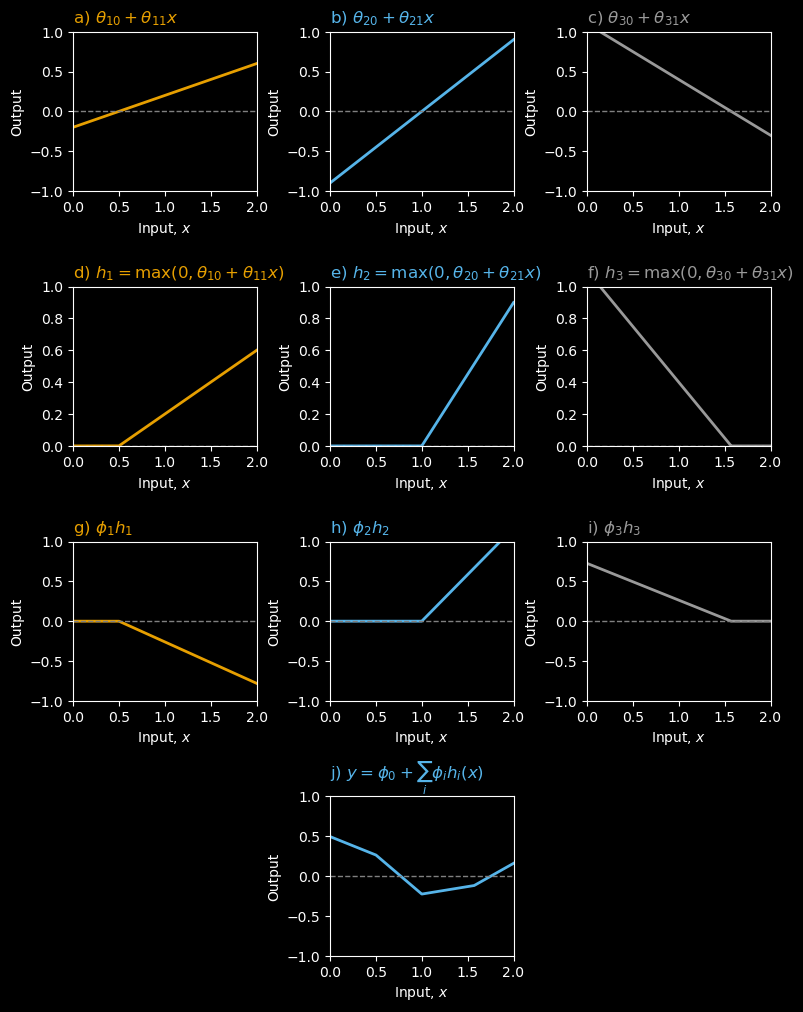

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# 1. Definimos los parámetros 
phi0, phi1, phi2, phi3 = -0.23, -1.3, 1.3, 0.66
theta10, theta11 = -0.2,  0.4
theta20, theta21 = -0.9,  0.9
theta30, theta31 =  1.1, -0.7
x = np.linspace(0, 2, 500)

# 2. Calculamos cada unidad oculta antes de activación: l_i(x) = θ_i0 + θ_i1 * x
l1 = theta10 + theta11 * x
l2 = theta20 + theta21 * x
l3 = theta30 + theta31 * x

# 3. Calculamos la función de activación: h_i(x) = max(0, ℓ_i(x))
h1 = np.maximum(0, l1)
h2 = np.maximum(0, l2)
h3 = np.maximum(0, l3)

# 4. Ponderamos las activaciones: φ_i * h_i(x)
w1 = phi1 * h1
w2 = phi2 * h2
w3 = phi3 * h3

# 5. Resultado de la red: y(x) = φ₀ + Σ φ_i h_i(x)
y = phi0 + w1 + w2 + w3

# 6) Graficamos: 
plt.style.use('dark_background')
fig = plt.figure(figsize=(9, 12))
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.6, wspace=0.4)
def zero_line(ax):
    ax.axhline(0, color='grey', linestyle='--', linewidth=1)
for i, (ℓ, col, title) in enumerate(zip(
    [l1, l2, l3],
    ["#E69F00", "#56B4E9", "#999999"],
    ["a) $\\theta_{10}+\\theta_{11}x$",
     "b) $\\theta_{20}+\\theta_{21}x$",
     "c) $\\theta_{30}+\\theta_{31}x$"]
  )):
    ax = fig.add_subplot(gs[0, i])
    ax.plot(x, ℓ, color=col, linewidth=2)
    zero_line(ax)
    ax.set_xlim(0,2); ax.set_ylim(-1,1)
    ax.set_title(title, loc='left', color=col, fontsize=12)
    ax.set_ylabel("Output")
    ax.set_xlabel("Input, $x$")
    ax.grid(False)
for i, (h, col, title) in enumerate(zip(
    [h1, h2, h3],
    ["#E69F00", "#56B4E9", "#999999"],
    ["d) $h_1=\\max(0,\\theta_{10}+\\theta_{11}x)$",
     "e) $h_2=\\max(0,\\theta_{20}+\\theta_{21}x)$",
     "f) $h_3=\\max(0,\\theta_{30}+\\theta_{31}x)$"]
  )):
    ax = fig.add_subplot(gs[1, i])
    ax.plot(x, h, color=col, linewidth=2)
    zero_line(ax)
    ax.set_xlim(0,2); ax.set_ylim(0,1)
    ax.set_title(title, loc='left', color=col, fontsize=12)
    ax.set_ylabel("Output")
    ax.set_xlabel("Input, $x$")
    ax.grid(False)
for i, (w, col, title) in enumerate(zip(
    [w1, w2, w3],
    ["#E69F00", "#56B4E9", "#999999"],
    ["g) $\\phi_1 h_1$",
     "h) $\\phi_2 h_2$",
     "i) $\\phi_3 h_3$"]
  )):
    ax = fig.add_subplot(gs[2, i])
    ax.plot(x, w, color=col, linewidth=2)
    zero_line(ax)
    ax.set_xlim(0,2); ax.set_ylim(-1,1)
    ax.set_title(title, loc='left', color=col, fontsize=12)
    ax.set_ylabel("Output")
    ax.set_xlabel("Input, $x$")
    ax.grid(False)
ax = fig.add_subplot(gs[3, 1])
ax.plot(x, y, color="#56B4E9", linewidth=2)
zero_line(ax)
ax.set_xlim(0,2); ax.set_ylim(-1,1)
ax.set_title("j) $y = \\phi_0 + \\sum_i \\phi_i h_i(x)$", loc='left', color="#56B4E9", fontsize=12)
ax.set_ylabel("Output")
ax.set_xlabel("Input, $x$")
ax.grid(False)

plt.show()

2. Vamos a construir una red neuronal desde 0 en python (gran parte de este código esta arriba) 

     a. Define la función de activación ReLU (tiene que ser una función en python)

     b. Define una red neuronal con 1 input, 1 output y 3 unidades ocultas (tiene que ser una función en python)

     c. Define una función que grafica tu red neuronal, asume que el rango del input es $[0,1]$ y que el rango del output es $[-1,1]$ (tiene que ser una función que recibe input, output, las pre activaciones, las activaciones y los pesos de cada activación). 

     d. Prueba tu código usando los siguientes parámetros: $\theta_{10} = 0.3$, $\theta_{11} = -1.0$, $\theta_{20} = -1.0$, $\theta_{21} = 2.0$, $\theta_{30} = -0.5$, $\theta_{31} = 0.65$, $\phi_0 = -0.3$, $\phi_1 = 2.0$, $\phi_2 = -1.0$, $\phi_3 = 7.0$


3. Usando el código que creaste y los parámetros para tu red vamos a evaluar lo siguiente. Para estas preguntas contesta con una oración o dos teoricamente que pasa ademas de correr tu código para ver graficamente que esta pasando con la red. 
    
    a. ¿Qué efecto tiene en la red cambiar $\phi_0$?

    b. ¿Qué efecto tiene multiplicar $phi_1, phi_2, phi_3$ por 0.5?

    c. ¿Qué efecto tiene multiplicar $phi_1$ por -1?

    d. Encuentra un conjunto de parámetros de tal manera que solo haya dos articulaciones en tu red (incluyendo el rango fuera de la gráfica). Existen tres maneras de hacer esto, encuentra al menos 1

    e. Con los parámetros originales el segundo segmento es una linea recta sin pendiente. ¿Cómo cambiarias $\theta_{10}$ para que ningun segmento tenga pendiente cero?

4. Considera la función de pérdida cuadrática: 

$$L(\phi) = \sum_{i=1}^I(y_i - f(x_i,\phi))^2$$

a. Escribe esta función de pérdida en python 

b. Usando los mismos parámetros que en las dos preguntas anteriores y los datos de entrenamiento de acá abajo: corre tu red en los datos de entrenamiento 

c. Calcula que tan bien o mal lo está haciendo está red 

d. Juega un poco con los parámetros e intenta reducir la función de pérdida. ¿Qué parametro parece más útil para hacer esto? 

In [3]:
x_train = np.array([0.09291784,0.46809093,0.93089486,0.67612654,0.73441752,0.86847339,\
                   0.49873225,0.51083168,0.18343972,0.99380898,0.27840809,0.38028817,\
                   0.12055708,0.56715537,0.92005746,0.77072270,0.85278176,0.05315950,\
                   0.87168699,0.58858043])
y_train = np.array([-0.15934537,0.18195445,0.451270150,0.13921448,0.09366691,0.30567674,\
                    0.372291170,0.40716968,-0.08131792,0.41187806,0.36943738,0.3994327,\
                    0.019062570,0.35820410,0.452564960,-0.0183121,0.02957665,-0.24354444, \
                    0.148038840,0.26824970])